<a href="https://colab.research.google.com/github/LaylaVenancio/machine-learning-wine-quality-classification/blob/main/Tech_Challange_2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Compreensão do Problema
---------


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay



In [35]:
df = pd.read_csv("/content/drive/MyDrive/Pós Graduação/Tech Challange 2/WineQT.csv")

In [36]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [37]:
df['high_quality'] = np.where(df['quality'] >= 7, 1, 0) #Criação da coluna binária da variável target
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,high_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


#2. Análise Exploratória de Dados (EDA)
---------


##2.1) Identificar correlações entre as variáveis e justificar cada uma delas



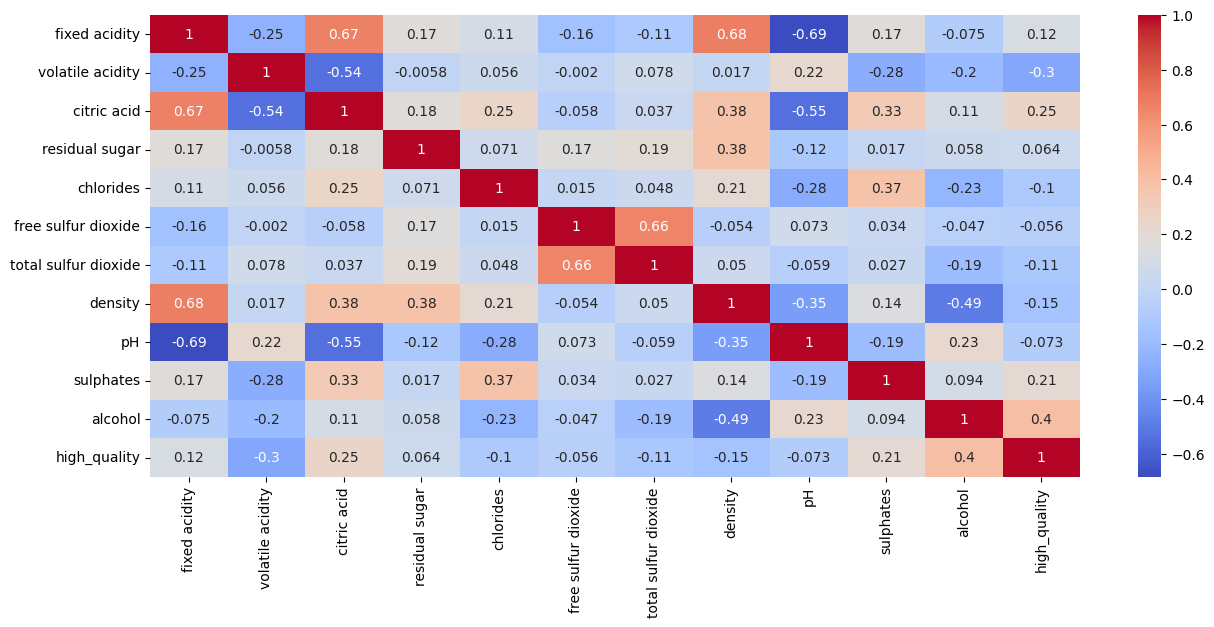

In [38]:
df_corr = df.drop(columns = ['Id','quality'])

plt.figure(figsize=(15,6))
corr = sns.heatmap(df_corr.corr(),annot= True,cmap='coolwarm')
plt.show()

##2.2) Investigue a distribuição das variáveis


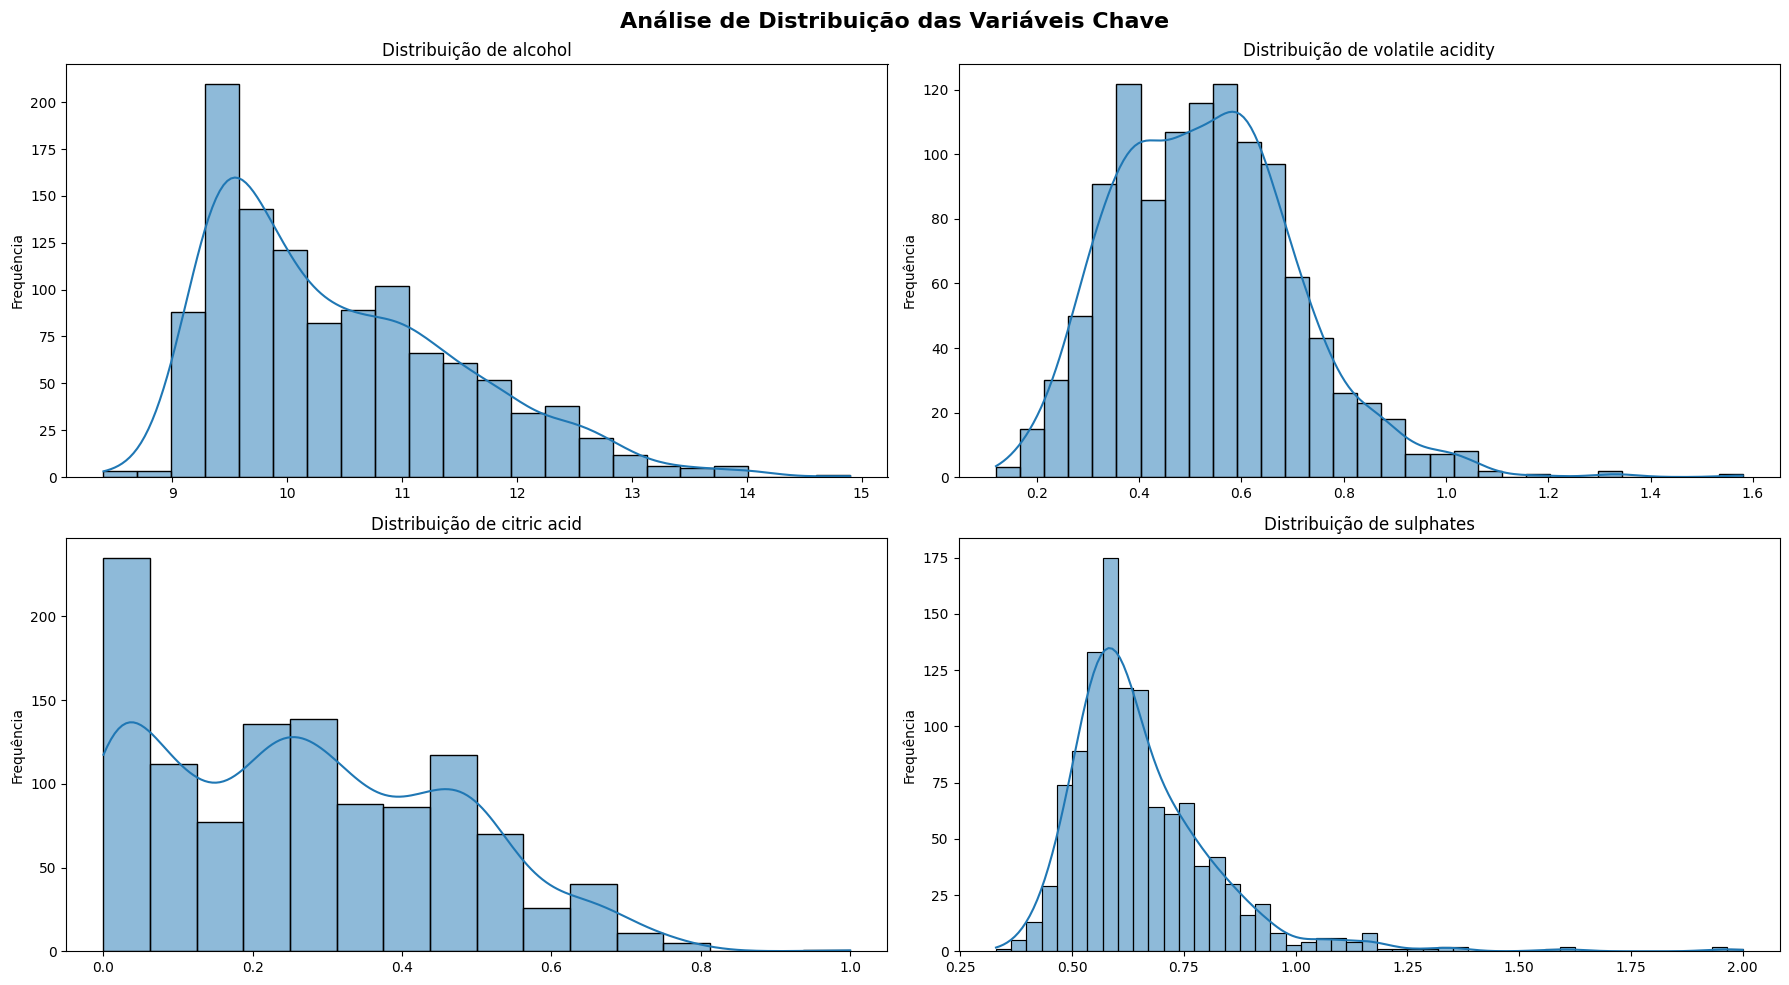

In [39]:
# Selecionando as variáveis chave (Correlação)
variaveis_chave = ['alcohol', 'volatile acidity', 'citric acid', 'sulphates',]

# Configurando a matriz de gráficos
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Análise de Distribuição das Variáveis Chave', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(variaveis_chave):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

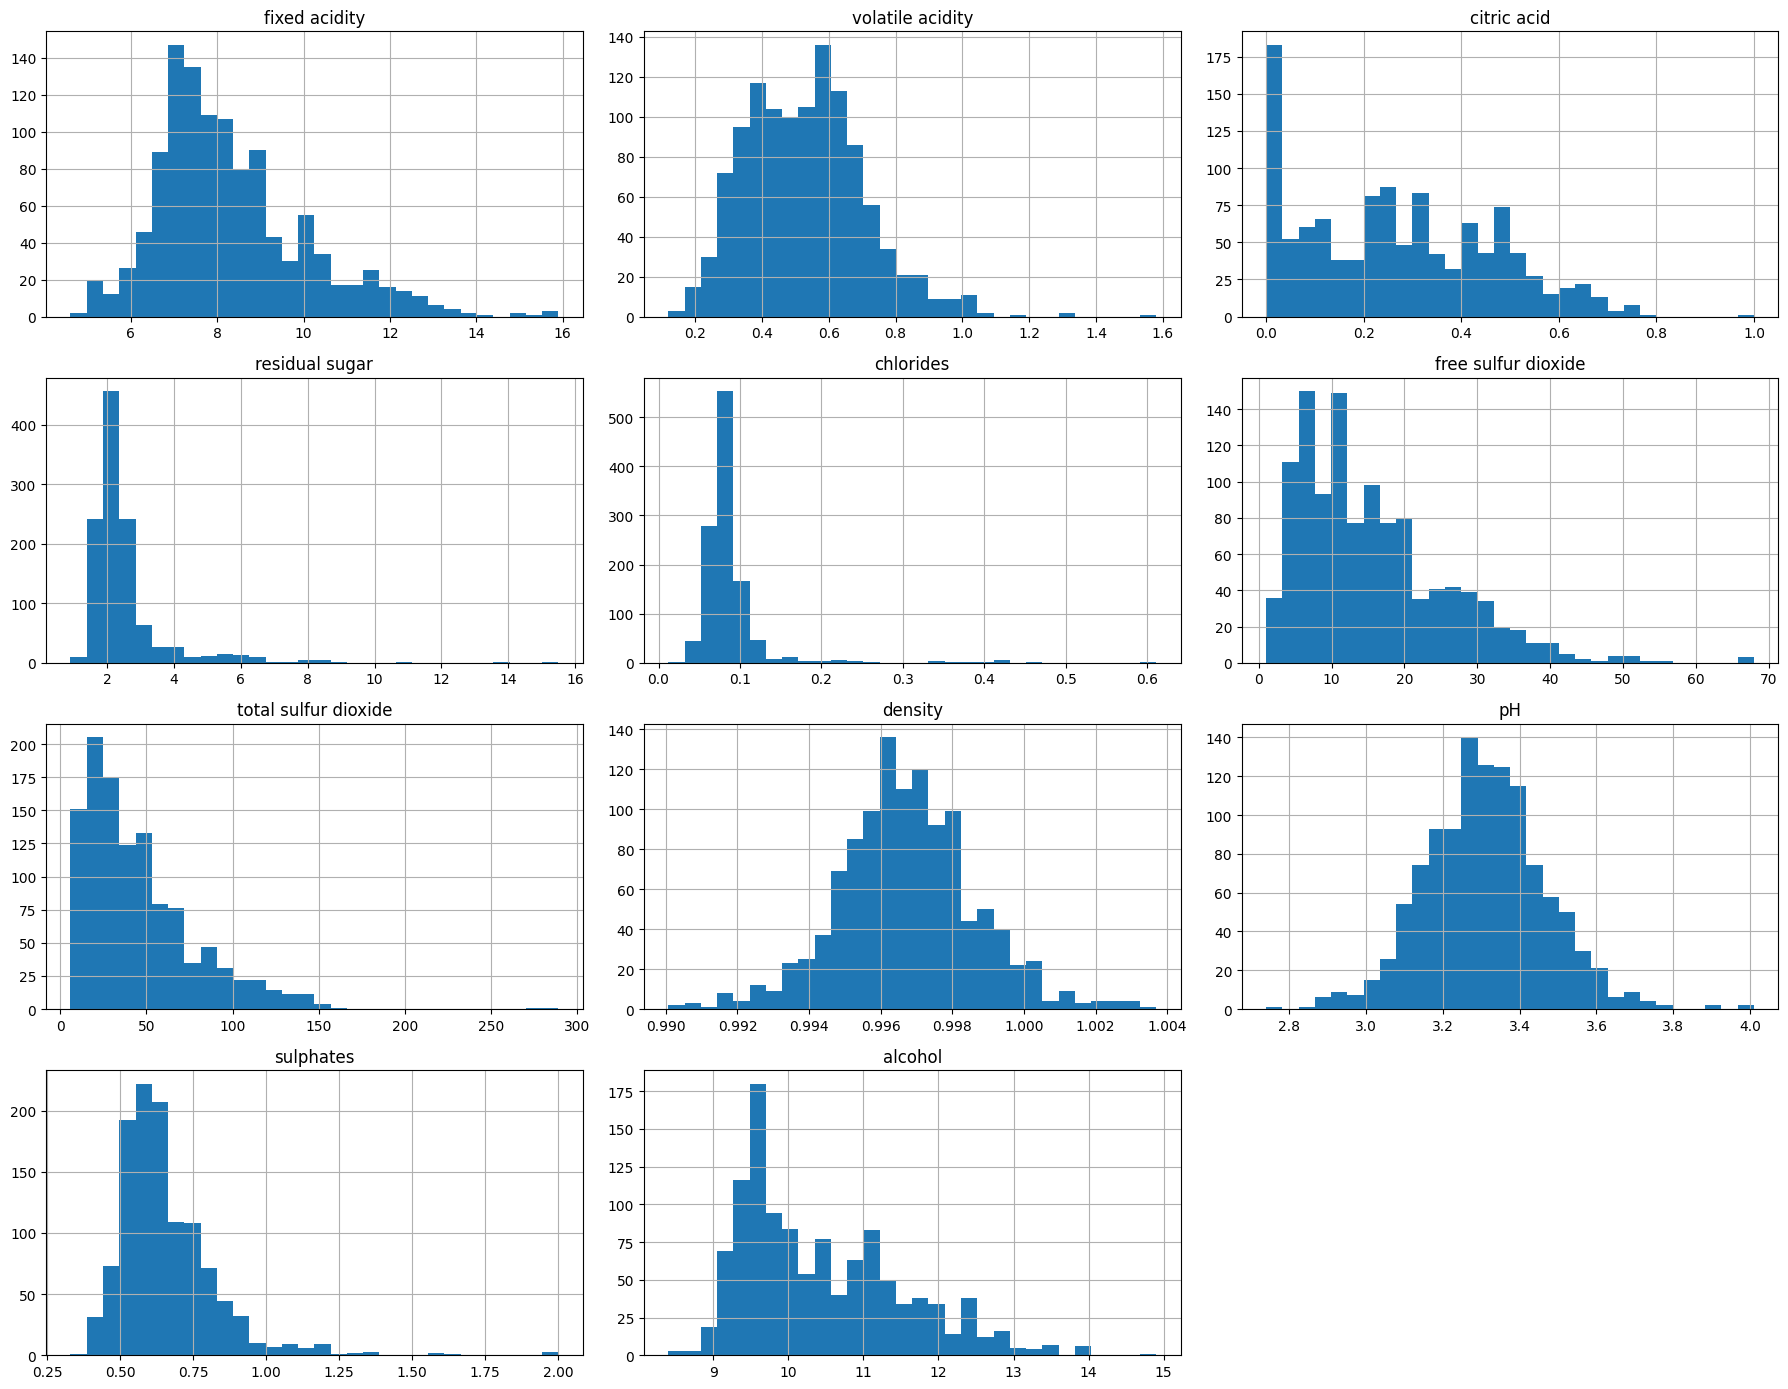

In [40]:
#histograma de todas as variáveis explicativas
df_histograma = df.drop(columns = ['Id','high_quality','quality'])
df_histograma.hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

<Axes: xlabel='high_quality', ylabel='alcohol'>

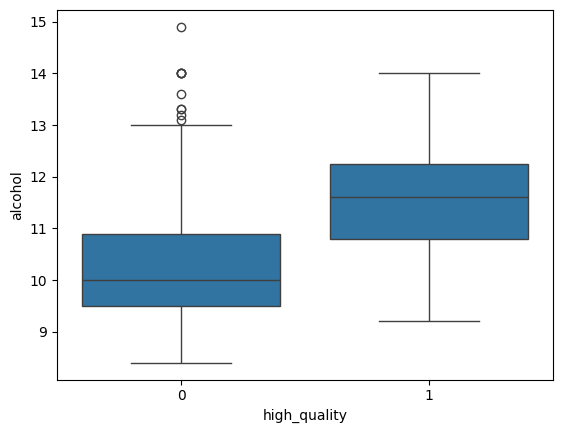

In [41]:
sns.boxplot(data = df, x = 'high_quality', y = 'alcohol',)

##2.3) Detectar possíveis outliers ou valores inconsistentes

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
 13  high_quality          1143 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 125.1 KB


In [43]:
df_sem_id = df.drop(columns=['Id'])

print(f'duplicatas dataset original: {df.duplicated().sum()}')
print(f'suplicatas dataset sem id: {df_sem_id.duplicated().sum()}')

duplicatas dataset original: 0
suplicatas dataset sem id: 125


In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


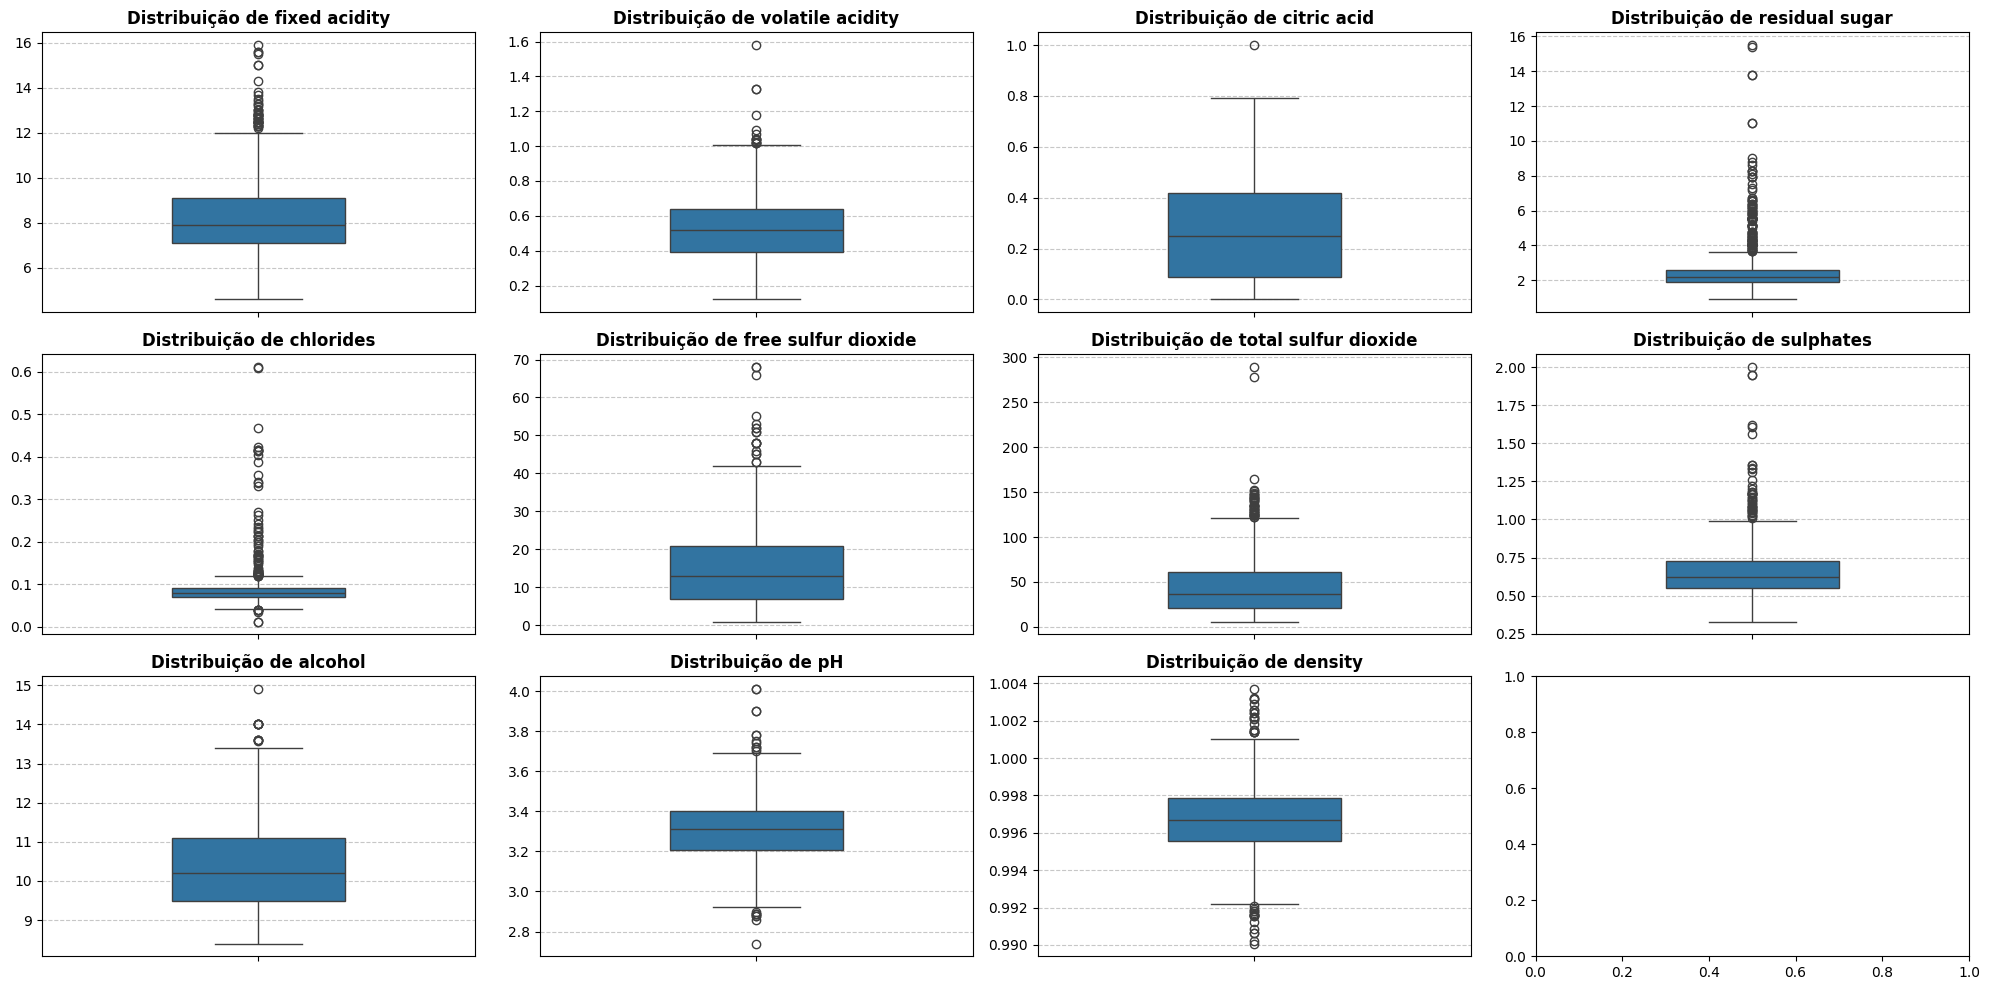

In [45]:
variaveis = [
    'fixed acidity','volatile acidity','citric acid', 'residual sugar', 'chlorides',
    'free sulfur dioxide', 'total sulfur dioxide', 'sulphates', 'alcohol', 'pH', 'density'
]

# Configura o tamanho da figura e o grid
fig, axes = plt.subplots(nrows=3, ncols= 4, figsize=(20, 10))

# Achata a matriz de eixos para iterar facilmente sobre ela
axes = axes.flatten()

# Loop para plotar cada boxplot em seu quadrante
for i, col in enumerate(variaveis):
    sns.boxplot(data=df, y=col, ax=axes[i], width=0.4)
    axes[i].set_title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')  # Remove o label repetido do eixo Y para limpar o visual
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)  # Linhas de grade discretas

# Ajusta o espaçamento para não sobrepor os títulos
plt.tight_layout()
plt.show()

##2.4) Analisar o balanceamento das classes

In [46]:
pd.concat([df['high_quality'].value_counts(),
           df['high_quality'].value_counts(normalize=True)*100],
          axis=1, keys=['Contagem', '% do Todo']).round(2)

,Contagem,% do Todo
high_quality,,
0,984,86.09
1,159,13.91


<Axes: xlabel='high_quality', ylabel='count'>

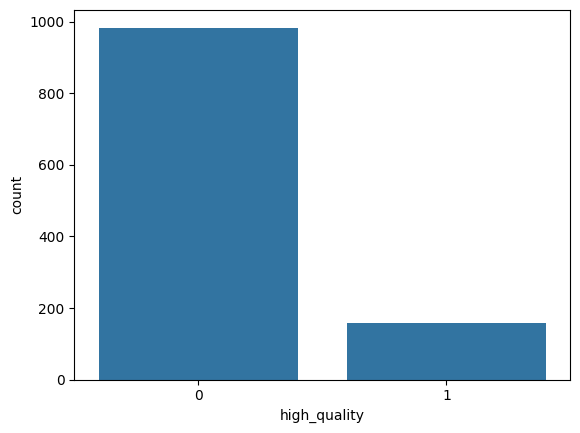

In [47]:
sns.countplot(x='high_quality', data=df)

#3. Pré-processamento do dado
----
● Tratamento de dados faltantes (se houver). <BR>
● Normalização ou padronização de variáveis numéricas. <BR>
● Criação de novas features (feature engineering), se considerado <BR>
relevante.

## 3.1 Tratamento de dados faltantes se houver

In [48]:
df_new = df.drop(columns = ['quality', 'Id'])

In [49]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  high_quality          1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [50]:
df_new.drop_duplicates(inplace=True)

In [51]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1018 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1018 non-null   float64
 1   volatile acidity      1018 non-null   float64
 2   citric acid           1018 non-null   float64
 3   residual sugar        1018 non-null   float64
 4   chlorides             1018 non-null   float64
 5   free sulfur dioxide   1018 non-null   float64
 6   total sulfur dioxide  1018 non-null   float64
 7   density               1018 non-null   float64
 8   pH                    1018 non-null   float64
 9   sulphates             1018 non-null   float64
 10  alcohol               1018 non-null   float64
 11  high_quality          1018 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 103.4 KB


## 3.2 Normalização ou padronização das variáveis numéricas
----


In [52]:
X = df_new.drop(columns=['high_quality'])
y = df_new['high_quality']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [54]:
print(f'Treino: {X_train.shape}')
print(f'Teste:  {X_test.shape}')

print(f'\nProporção no treino: {y_train.value_counts(normalize=True).round(3)}')
print(f'Proporção no teste:  {y_test.value_counts(normalize=True).round(3)}')

Treino: (814, 11)
Teste:  (204, 11)

Proporção no treino: high_quality
0    0.865
1    0.135
Name: proportion, dtype: float64
Proporção no teste:  high_quality
0    0.868
1    0.132
Name: proportion, dtype: float64


In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
print(f'Shape treino escalado: {X_train_scaled.shape}')
print(f'Média após escala: {X_train_scaled.mean(axis=0).round(2)}')
print(f'Desvio após escala: {X_train_scaled.std(axis=0).round(2)}')

Shape treino escalado: (814, 11)
Média após escala: [-0.  0.  0.  0.  0.  0.  0. -0.  0.  0. -0.]
Desvio após escala: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


#4. Desenvolvimento de Modelos
----
Treinar pelo menos dois modelos de classificação, e comparar o desempenho
entre eles.

<br> Comentário:
<br> Optei por treinar o KNN e o Random Forest. O motivo disso, é que se tratam de modelos de natureza diferente, o KNN classifica os dados com base na distância entre os seus vizinhos e o Random Forest treina diversas árvores de decisão, que fazem perguntar para dividir e classificar os dados. <br> A hipótese é que o Random Forest se saia melhor, por conta do KNN sofrer mais com o desbalancemanto da classe target

In [57]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 4.1 KNN
----
Algoritmo não paramétrico que classifica novos dados baseando-se nas distâncias entre  “K” pontos no espaço. Por exemplo, se determinamos que k = 3, cada novo dado é determinado pela classe dominante dos 3 vizinhos mais próximos. Nesse contexto, se dois deles são da classe “bom” e um da classe “ruim”, o novo dado será determinado como “bom”.

Para a escolha do K, a métrica utilizada foi o F1 Score porque ele é a mais adequada para classes minoritárias, equilibrando precisão e recall


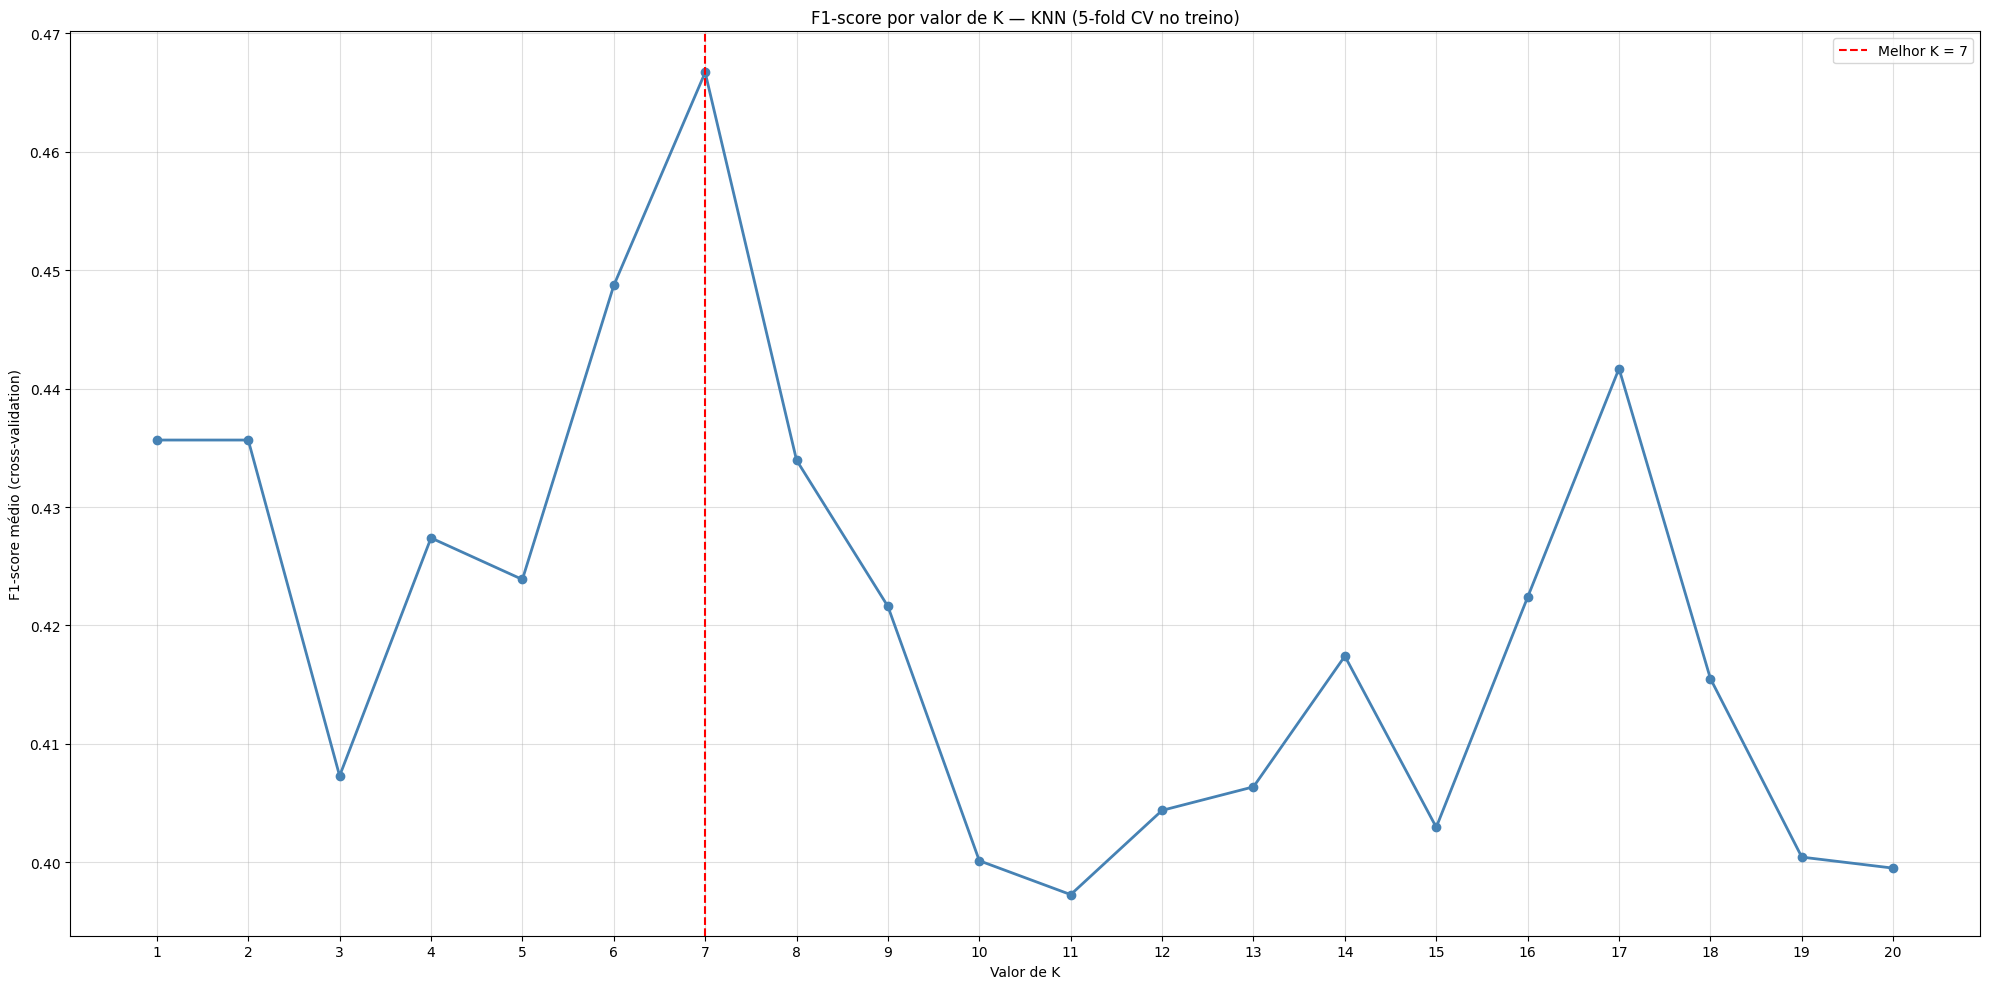

In [58]:
k_values = range(1, 21)
cv_f1_scores_knn = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='f1')
    cv_f1_scores_knn.append(scores.mean())

melhor_k = list(k_values)[np.argmax(cv_f1_scores_knn)]

plt.figure(figsize=(20, 10))
plt.plot(k_values, cv_f1_scores_knn, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=melhor_k, color='red', linestyle='--', label=f'Melhor K = {melhor_k}')
plt.xlabel('Valor de K')
plt.ylabel('F1-score médio (cross-validation)')
plt.title('F1-score por valor de K — KNN (5-fold CV no treino)')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [59]:
modelo_KNN = KNeighborsClassifier(n_neighbors=melhor_k, weights='distance')

In [60]:
modelo_KNN.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7, weights='distance')

In [61]:
y_pred_knn = modelo_KNN.predict(X_test_scaled)

## 4.2 Random Forest

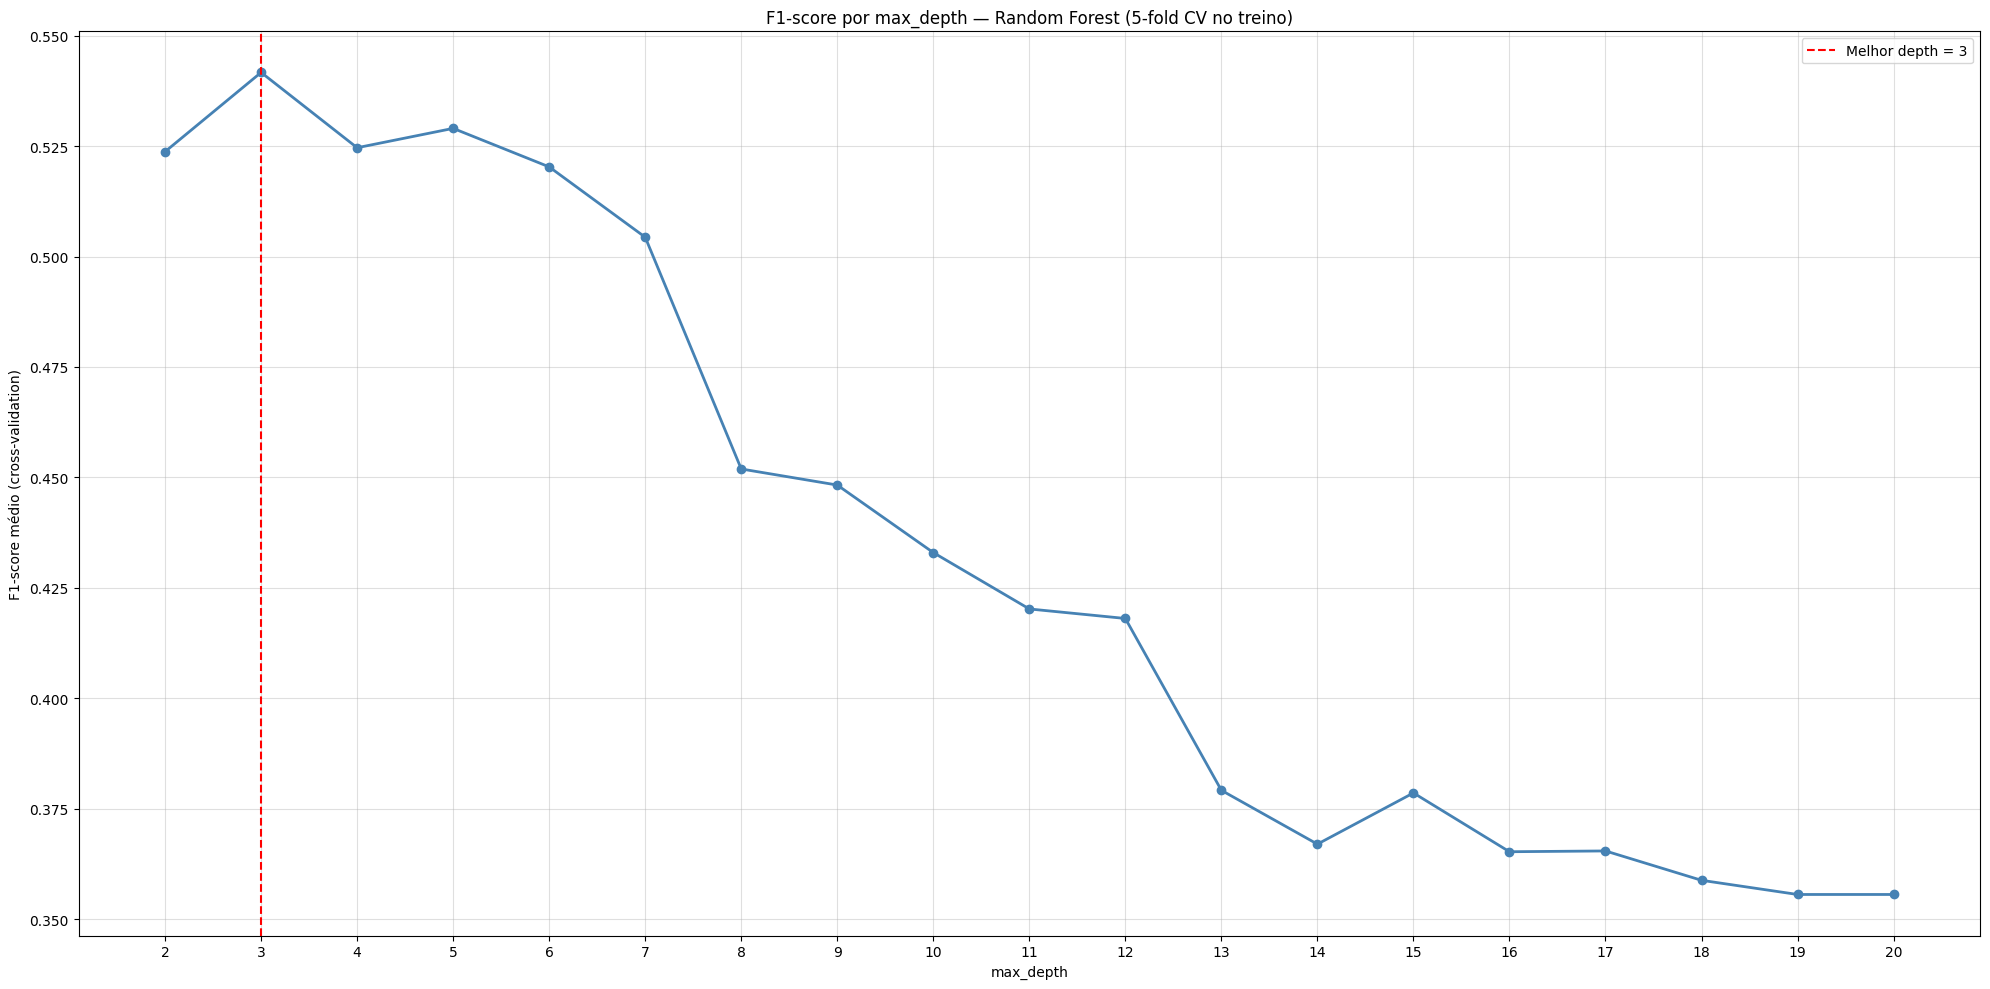

In [62]:
max_depths = range(2, 21)
cv_f1_scores_rf = []

for depth in max_depths:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1')
    cv_f1_scores_rf.append(scores.mean())

melhor_depth = list(max_depths)[np.argmax(cv_f1_scores_rf)]

plt.figure(figsize=(20, 10))
plt.plot(max_depths, cv_f1_scores_rf, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=melhor_depth, color='red', linestyle='--', label=f'Melhor depth = {melhor_depth}')
plt.xlabel('max_depth')
plt.ylabel('F1-score médio (cross-validation)')
plt.title('F1-score por max_depth — Random Forest (5-fold CV no treino)')
plt.xticks(max_depths)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

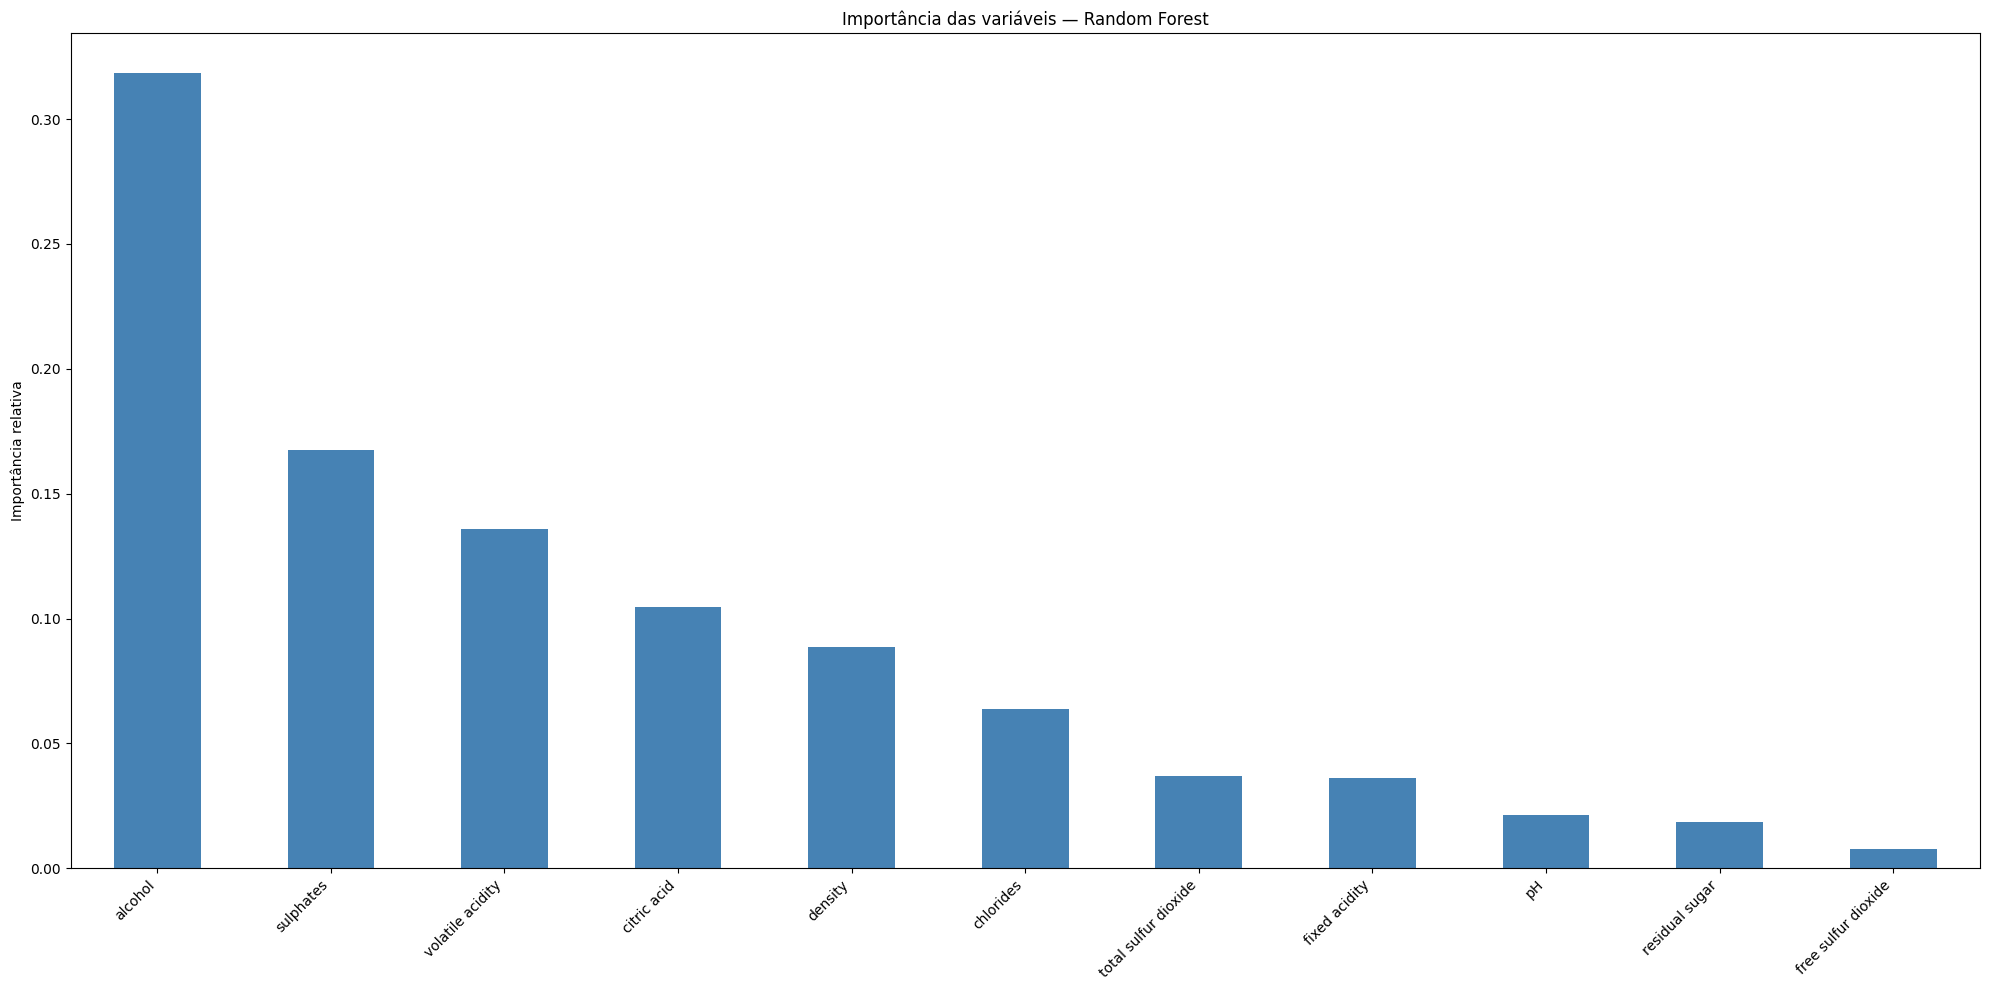

In [63]:
modelo_RF_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=melhor_depth,
    class_weight='balanced',
    random_state=42
)
modelo_RF_final.fit(X_train, y_train)
y_pred_rf = modelo_RF_final.predict(X_test)


importancias = (
    pd.Series(modelo_RF_final.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

plt.figure(figsize=(20, 10))
importancias.plot(kind='bar', color='steelblue')
plt.title('Importância das variáveis — Random Forest')
plt.ylabel('Importância relativa')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#5. Avaliação dos Modelos
----
Avaliar os modelos utilizando métricas adequadas. Também deve ser realizada
uma comparação entre os modelos testados.

In [64]:
report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
report_rf  = classification_report(y_test, y_pred_rf,  output_dict=True)

comparacao = pd.DataFrame({
    'KNN':           [report_knn['accuracy'],
                      report_knn['1']['precision'],
                      report_knn['1']['recall'],
                      report_knn['1']['f1-score']],
    'Random Forest': [report_rf['accuracy'],
                      report_rf['1']['precision'],
                      report_rf['1']['recall'],
                      report_rf['1']['f1-score']],
}, index=['Acurácia geral', 'Precisão (classe 1)', 'Recall (classe 1)', 'F1-score (classe 1)'])

comparacao.round(3)

,KNN,Random Forest
Acurácia geral,0.897,0.848
Precisão (classe 1),0.650,0.455
Recall (classe 1),0.481,0.741
F1-score (classe 1),0.553,0.563


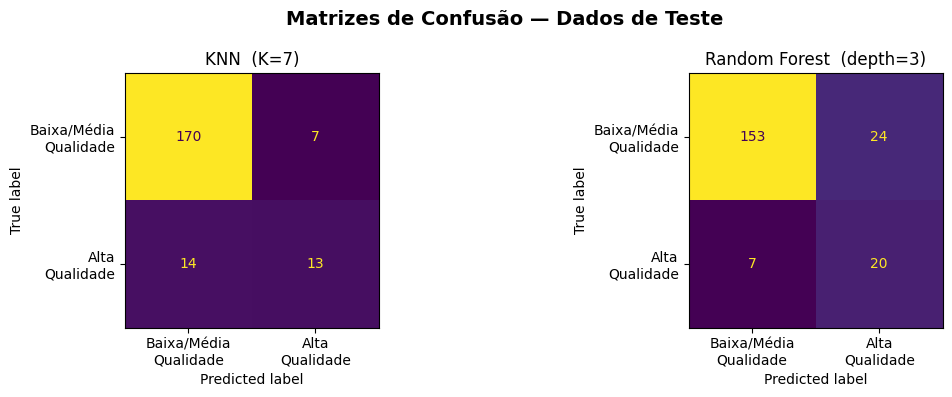

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Matrizes de Confusão — Dados de Teste', fontsize=14, fontweight='bold')

labels = ['Baixa/Média\nQualidade', 'Alta\nQualidade']

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_knn, y_pred_rf],
    [f'KNN  (K={melhor_k})', f'Random Forest  (depth={melhor_depth})']
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=labels,
        colorbar=False,
        ax=ax
    )
    ax.set_title(titulo, fontsize=12)

plt.tight_layout()
plt.show()

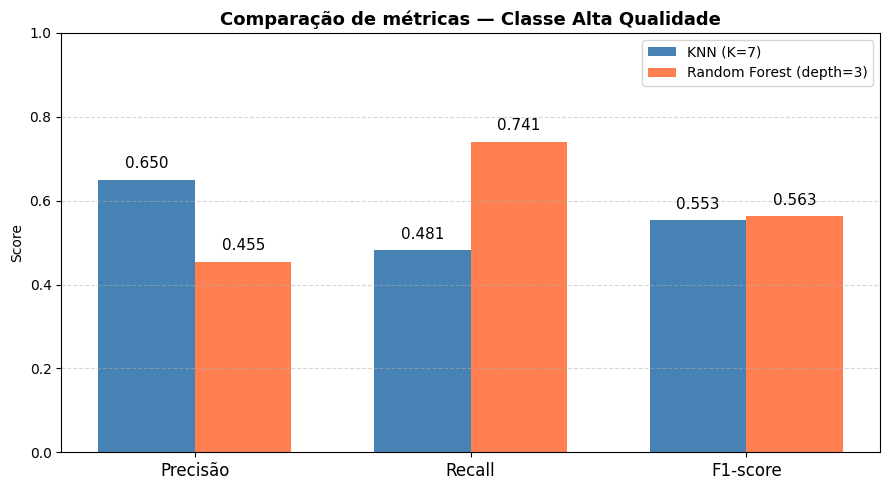

In [66]:
metricas = ['Precisão', 'Recall', 'F1-score']
valores_knn = [report_knn['1']['precision'],
               report_knn['1']['recall'],
               report_knn['1']['f1-score']]
valores_rf  = [report_rf['1']['precision'],
               report_rf['1']['recall'],
               report_rf['1']['f1-score']]

x = np.arange(len(metricas))
largura = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
barras_knn = ax.bar(x - largura/2, valores_knn, largura, label=f'KNN (K={melhor_k})',            color='steelblue')
barras_rf  = ax.bar(x + largura/2, valores_rf,  largura, label=f'Random Forest (depth={melhor_depth})', color='coral')

ax.set_title('Comparação de métricas — Classe Alta Qualidade', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Rótulos em cima de cada barra
for barra in barras_knn:
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.02,
            f'{barra.get_height():.3f}', ha='center', va='bottom', fontsize=11)
for barra in barras_rf:
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.02,
            f'{barra.get_height():.3f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()